In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [4]:
df.rename(columns={'3.159499363321345566e-02' : 'X', '9.869877579082642072e-01' : 'Y', '0.000000000000000000e+00' : 'class'}, inplace=True)

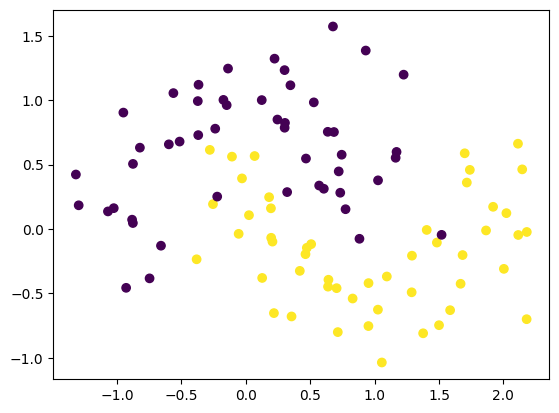

In [5]:
plt.scatter(x = df['X'], y=df['Y'], c=df['class'])

In [6]:
X = df.iloc[:, 0:2].values
Y = df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [8]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\ABDULLAH AL MASUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.get_weights()

[array([[ 0.18471646,  0.24421132,  0.2873999 ,  0.6544922 , -0.2945515 ,
         -0.38871026,  0.21146154,  0.21533668, -0.60123   ,  0.17731345],
        [-0.5316365 ,  0.3400244 ,  0.35200125, -0.39876246, -0.6842185 ,
         -0.4218778 , -0.14531034,  0.590022  ,  0.05630195,  0.01418883]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 3.56109202e-01, -3.25919241e-01, -4.65344787e-02,
          3.57809544e-01,  4.38561022e-01,  5.38696289e-01,
         -3.25402915e-01,  5.04376888e-01, -3.77908766e-01,
          1.97130203e-01],
        [-5.29627085e-01, -4.43982780e-01,  5.13075709e-01,
         -3.54061723e-01, -2.45725751e-01, -1.58470482e-01,
         -7.56442547e-03,  6.28658533e-02,  5.08558393e-01,
          3.93619180e-01],
        [-5.36045492e-01,  1.38054848e-01, -3.51456225e-01,
         -3.23967606e-01, -4.25752789e-01, -4.30274248e-01,
         -2.02559352e-01, -5.14130712e-01, -3.18809152e-01,
          1.3430964

In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(X, Y, epochs=100, validation_split=.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.4430 - loss: 0.6998 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4810 - loss: 0.6948 - val_accuracy: 0.6500 - val_loss: 0.6904
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5696 - loss: 0.6912 - val_accuracy: 0.7000 - val_loss: 0.6856
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7722 - loss: 0.6867 - val_accuracy: 0.8500 - val_loss: 0.6813
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7975 - loss: 0.6835 - val_accuracy: 0.8500 - val_loss: 0.6782
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8228 - loss: 0.6806 - val_accuracy: 0.8000 - val_loss: 0.6749
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8608 - loss: 0.6779 - val_accuracy: 0.8000 - val_loss: 0.6718
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8481 - loss: 0.6752 - val_accuracy: 0.8000 - val_loss

In [13]:
model.predict(np.array([[0.882490,	-0.075756]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


array([[0.8602469]], dtype=float32)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

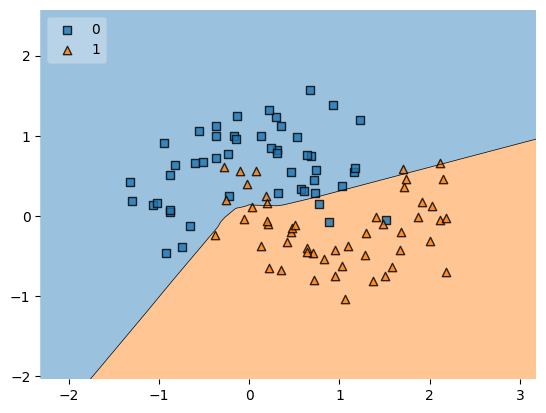

In [14]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, Y.astype('int'), clf=model, legend=2)

# Uniform Distribution

In [15]:
model2 = Sequential()

model2.add(Dense(10, activation='relu', input_dim=2, kernel_initializer='he_uniform'))
model2.add(Dense(10, activation='relu' ,kernel_initializer='he_uniform'))
model2.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model2.add(Dense(10, activation='relu', kernel_initializer='he_uniform'))
model2.add(Dense(1, activation='sigmoid'))

In [16]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model2.get_weights()

[array([[-0.6341746 , -1.5892029 , -0.11282659,  1.104489  ,  0.9480225 ,
         -0.89252335, -0.57440746,  0.61634934, -0.0369432 , -0.0105406 ],
        [-1.1823466 ,  1.0850755 , -0.17292655,  0.7477609 , -1.1604445 ,
          0.33524883, -0.3256408 , -1.3208528 ,  1.2506751 ,  0.70525324]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.10358101,  0.42677152,  0.49977565, -0.45397237, -0.72637093,
         -0.182931  ,  0.02740383, -0.09127206,  0.7682458 ,  0.30547   ],
        [-0.18829423, -0.05866653, -0.31258288, -0.13818866, -0.26418054,
         -0.15279263, -0.31269386,  0.17459983, -0.2692548 ,  0.42271543],
        [-0.3358917 ,  0.65778637, -0.3081663 , -0.5057933 , -0.7032302 ,
         -0.23112833,  0.37422478, -0.60106635, -0.70078725, -0.25800347],
        [ 0.07577258, -0.4697151 , -0.31816146,  0.57091916, -0.06964016,
          0.04325736, -0.22354436,  0.13452202, -0.477623  , -0.09710807],
        [ 0.55969

In [18]:
inittial_weights = model2.get_weights()

In [19]:
inittial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
inittial_weights[1] = np.zeros(model2.get_weights()[1].shape)
inittial_weights[2] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[3] = np.zeros(model2.get_weights()[3].shape)
inittial_weights[4] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[5] = np.zeros(model2.get_weights()[5].shape)
inittial_weights[6] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[7] = np.zeros(model2.get_weights()[7].shape)
inittial_weights[8] = np.random.randn(10,1)*np.sqrt(1/2)
inittial_weights[9] = np.zeros(model2.get_weights()[9].shape)

In [20]:
model2.set_weights(inittial_weights)

In [21]:
model2.get_weights()

[array([[-0.5319888 ,  0.5267021 ,  0.4973845 ,  0.38251838,  0.58665127,
          0.16753241,  0.1407315 , -0.52672297,  0.5429988 , -0.67627835],
        [-1.5231528 , -0.3602946 ,  0.95814824,  0.17061688, -1.1948259 ,
         -0.5915231 ,  0.62937826,  0.86162263,  0.3358729 , -1.4144214 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-1.07438374e+00,  7.66561270e-01,  2.42458776e-01,
         -1.41800076e-01,  2.72889376e-01, -1.18229282e+00,
          1.22966421e+00,  4.48893040e-01, -3.06541741e-01,
          3.41240346e-01],
        [-2.75330059e-02, -1.32339910e-01, -2.15673260e-02,
          5.64486757e-02, -2.55013198e-01, -4.35210973e-01,
          1.31662762e+00, -3.47693712e-02,  8.17024261e-02,
         -5.59010983e-01],
        [ 8.61620232e-02, -6.52271688e-01,  3.07790101e-01,
          6.70049310e-01,  5.68731606e-01,  6.74071848e-01,
          1.17385507e-01,  6.44799918e-02,  6.78390145e-01,
          2.6546117

In [22]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
history2 = model2.fit(X, Y, epochs=100, validation_split=.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.4937 - loss: 4.7050 - val_accuracy: 0.5000 - val_loss: 3.8964
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4937 - loss: 4.3719 - val_accuracy: 0.5000 - val_loss: 3.5946
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4937 - loss: 4.0483 - val_accuracy: 0.5000 - val_loss: 3.3030
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4937 - loss: 3.7399 - val_accuracy: 0.5000 - val_loss: 3.0262
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4937 - loss: 3.4474 - val_accuracy: 0.5000 - val_loss: 2.7611
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4937 - loss: 3.1661 - val_accuracy: 0.5000 - val_loss: 2.5075
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4937 - loss: 2.9046 - val_accuracy: 0.5000 - val_loss: 2.2724
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5063 - loss: 2.6612 - val_accuracy: 0.5000 - val_loss

In [24]:
model2.get_weights()

[array([[-0.49581277,  0.4658255 ,  0.470941  ,  0.4606637 ,  0.50924516,
          0.18976821,  0.22209734, -0.41377863,  0.5085925 , -0.7721103 ],
        [-1.5641272 , -0.31565943,  0.9649642 ,  0.08597714, -1.1378992 ,
         -0.47540173,  0.6860752 ,  0.7668848 ,  0.3172358 , -1.3396219 ]],
       dtype=float32),
 array([ 0.05864576, -0.05765793, -0.02179163,  0.06836712, -0.10009199,
        -0.02369671,  0.09646703, -0.08805753, -0.02337817, -0.05174233],
       dtype=float32),
 array([[-1.2056485 ,  0.8214569 ,  0.31905767,  0.02370336,  0.27448252,
         -1.1822928 ,  1.1829779 ,  0.5359141 , -0.24966401,  0.30082443],
        [-0.14409295, -0.06652242,  0.07416417,  0.04203783, -0.29864118,
         -0.54638916,  1.2570597 , -0.04849689,  0.14441036, -0.5970034 ],
        [ 0.01072095, -0.5855399 ,  0.3965752 ,  0.678188  ,  0.5313074 ,
          0.5522879 ,  0.05519819,  0.02524253,  0.72485495,  0.26546118],
        [-0.3586005 ,  0.9657017 ,  0.80469483, -0.41288483, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 963us/step


<Axes: >

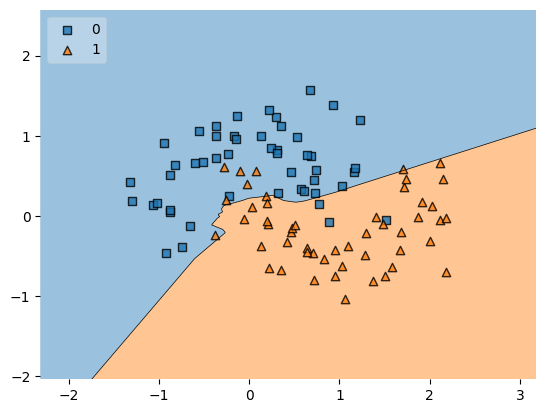

In [25]:
plot_decision_regions(X,Y.astype('int'), clf=model2, legend=2)

# Normal Distribution

In [26]:
model3 = Sequential()

model3.add(Dense(10, activation='relu', input_dim=2, kernel_initializer='he_normal'))
model3.add(Dense(10, activation='relu' ,kernel_initializer='he_normal'))
model3.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model3.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model3.add(Dense(1, activation='sigmoid'))

In [27]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model3.get_weights()

[array([[-0.21128014, -0.23304157,  0.255436  , -1.2050037 , -0.5114515 ,
         -1.1014934 , -0.72907984,  1.9527048 , -0.86577374, -0.14967749],
        [-0.9241059 , -1.3498396 , -0.5336312 ,  0.00829159,  0.19317143,
          0.18098484,  0.7364778 ,  0.22160457,  0.0730346 ,  0.34547877]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 7.89566159e-01,  2.35179648e-01, -1.69181954e-02,
         -3.26884598e-01,  5.44144154e-01, -6.70936704e-03,
          6.42434895e-01, -5.83881177e-02, -2.34932631e-01,
         -5.64466715e-02],
        [ 1.51073232e-01, -3.81225795e-01, -4.23460066e-01,
          7.58115947e-01, -1.52094290e-01,  2.08409652e-01,
          9.96623993e-01, -4.49779987e-01, -4.86290678e-02,
          3.59716594e-01],
        [-1.14988267e-01, -5.04220009e-01,  3.04345906e-01,
          2.14964464e-01,  1.23642283e-04, -3.58757645e-01,
          8.27625468e-02,  6.40706345e-02, -7.10949004e-02,
         -4.3447071

In [29]:
inittial_weights = model3.get_weights()

In [30]:
inittial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
inittial_weights[1] = np.zeros(model3.get_weights()[1].shape)
inittial_weights[2] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[3] = np.zeros(model3.get_weights()[3].shape)
inittial_weights[4] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[5] = np.zeros(model3.get_weights()[5].shape)
inittial_weights[6] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[7] = np.zeros(model3.get_weights()[7].shape)
inittial_weights[8] = np.random.randn(10,1)*np.sqrt(1/2)
inittial_weights[9] = np.zeros(model3.get_weights()[9].shape)

In [31]:
model3.set_weights(inittial_weights)

In [32]:
model3.get_weights()

[array([[-0.18245848,  0.032105  , -0.06091595,  0.18074705,  1.3269476 ,
          0.41591257,  0.04637754,  0.2216429 ,  0.4998791 ,  0.64057475],
        [ 0.05217346, -0.57284266,  0.76572704, -0.00954653,  0.3306251 ,
         -0.22711319, -0.15252379, -0.6974314 , -0.16025828,  0.3068273 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.27219006,  0.3044386 ,  0.17103018,  0.05093316, -1.2073534 ,
          0.62603277,  0.17059584, -0.5959766 , -0.10433341,  1.489569  ],
        [-0.981793  ,  0.71600413, -1.3582308 ,  0.76561075, -0.7131872 ,
          0.00870064,  0.1829532 , -1.1817334 , -1.5301327 , -0.07495011],
        [ 0.8575399 ,  0.14495762,  0.6869792 ,  0.4922748 , -1.1310401 ,
          0.95611125, -0.06172355,  0.45226815,  0.43592492, -0.9803633 ],
        [ 0.06430157,  0.2295731 , -0.8364714 ,  0.14522853, -0.30169147,
          0.6999896 , -0.39536798, -0.6202135 ,  0.2019181 , -0.9978763 ],
        [ 0.77087

In [33]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [34]:
history2 = model3.fit(X, Y, epochs=100, validation_split=.2)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4051 - loss: 0.6990 - val_accuracy: 0.5000 - val_loss: 0.6514
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4557 - loss: 0.6749 - val_accuracy: 0.6500 - val_loss: 0.6291
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6962 - loss: 0.6557 - val_accuracy: 0.8000 - val_loss: 0.6098
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6962 - loss: 0.6403 - val_accuracy: 0.8000 - val_loss: 0.5942
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7089 - loss: 0.6247 - val_accuracy: 0.8000 - val_loss: 0.5809
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6962 - loss: 0.6114 - val_accuracy: 0.8000 - val_loss: 0.5690
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7089 - loss: 0.5995 - val_accuracy: 0.8000 - val_loss: 0.5568
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7089 - loss: 0.5867 - val_accuracy: 0.8500 - val_loss: 0.5452
Epo

In [35]:
model3.get_weights()

[array([[-0.42904815,  0.06866372, -0.18697041,  0.24984711,  1.2901669 ,
          0.46843192,  0.00793207,  0.21827431,  0.43117848,  0.7416347 ],
        [ 0.07237663, -0.61975574,  0.8611353 ,  0.11104941,  0.24222139,
         -0.38548562, -0.12126436, -0.7255714 , -0.31223613,  0.41037843]],
       dtype=float32),
 array([-0.05614222, -0.04223232,  0.09404705,  0.012439  , -0.05646222,
         0.07246021, -0.04247174,  0.05123518, -0.1298397 ,  0.04164758],
       dtype=float32),
 array([[-0.29640457,  0.54282844,  0.3978591 ,  0.08094363, -1.2073534 ,
          0.8773042 ,  0.33238506, -0.66471565, -0.25847578,  1.3018173 ],
        [-1.0872371 ,  0.64146227, -1.3230592 ,  0.95942396, -0.7703169 ,
          0.00358644,  0.35114512, -1.0661805 , -1.5625168 , -0.1412401 ],
        [ 0.9396053 ,  0.2535655 ,  0.7307848 ,  0.46731025, -1.1214236 ,
          1.0753309 ,  0.10413063,  0.39394304,  0.3915356 , -1.1170716 ],
        [ 0.1758003 ,  0.3281857 , -0.896229  ,  0.16402073, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

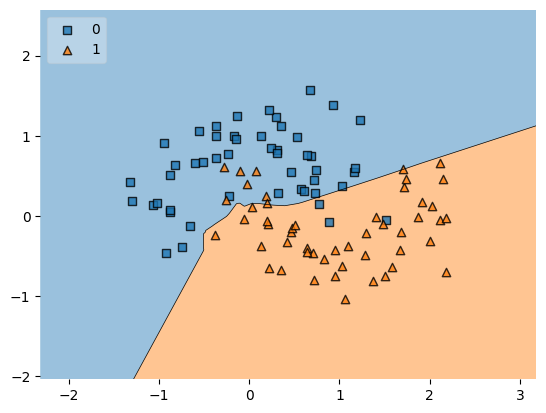

In [36]:
plot_decision_regions(X,Y.astype('int'), clf=model3, legend=2)